In [1]:
import os
import torch
import torchvision
import random
import matplotlib.pyplot as plt
import torchvision.models as models
import torch.nn as nn
from collections import Counter
import torch.nn.functional as F
from torch.utils.data import random_split
from torch.utils.data.dataloader import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = "/content/drive/MyDrive/Garbage classification"
classes = [f for f in os.listdir(data) if not f.startswith('.')]
print(classes)

['cardboard', 'plastic', 'glass', 'paper', 'metal', 'trash']


In [4]:
transformation = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.ToTensor()
  ])

dataset = ImageFolder(data, transform=transformation)

In [5]:
labels = dataset.targets

count_per_class = Counter(labels)

for i, class_name in enumerate(dataset.classes):
    print(f"{class_name:<10} → {count_per_class[i]} samples")

print("="*25)

total_samples = sum(count_per_class.values())
print("Total samples:", total_samples)

cardboard  → 403 samples
glass      → 501 samples
metal      → 410 samples
paper      → 594 samples
plastic    → 482 samples
trash      → 137 samples
Total samples: 2527


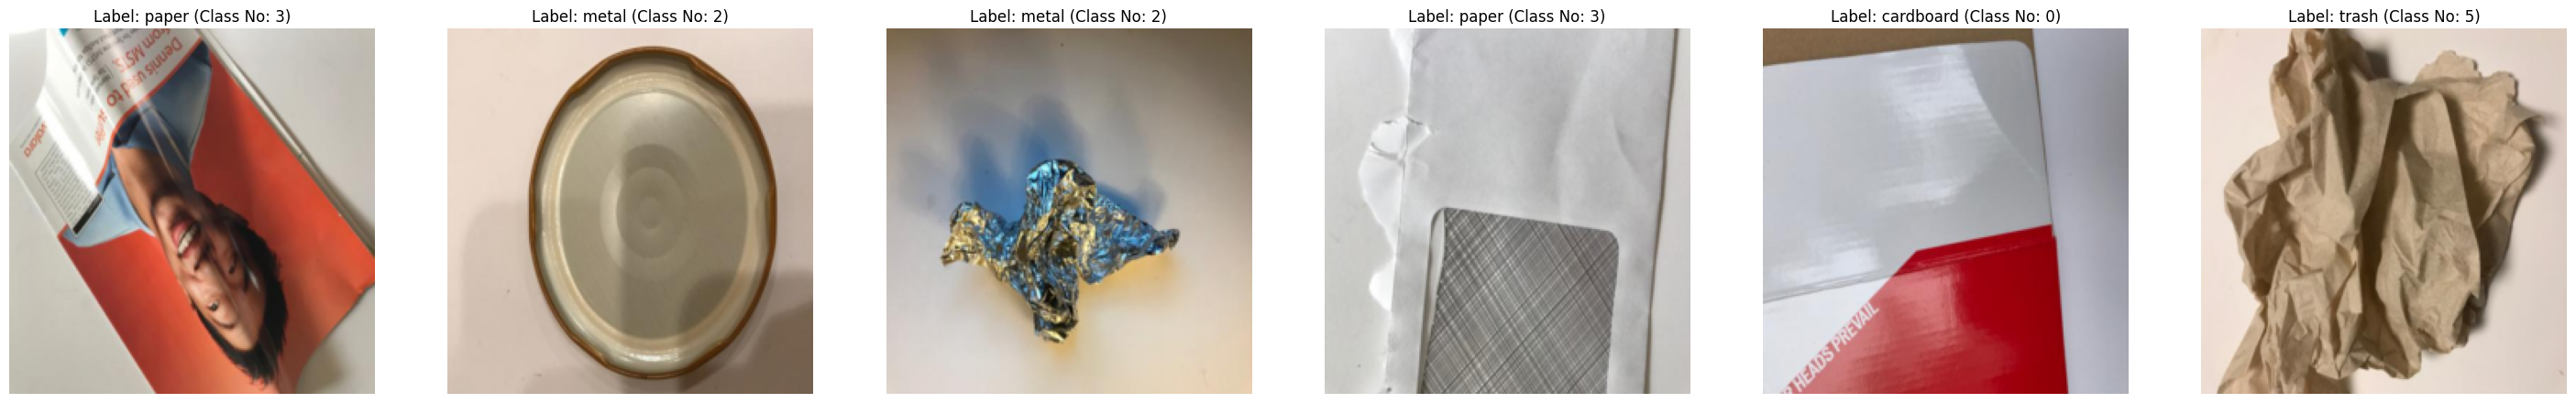

In [6]:
def show_random_samples(num_samples):
    indices = random.sample(range(len(dataset)), num_samples)

    plt.figure(figsize=(6 * num_samples, 6))

    for i, idx in enumerate(indices):
        img, label = dataset[idx]

        title = f"Label: {dataset.classes[label]} (Class No: {label})"

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img.permute(1, 2, 0))
        plt.title(title)
        plt.axis("off")

    plt.show()


show_random_samples(6)

In [7]:
# Loading and Splitting Data into Train, Test and Validation
torch.manual_seed(42)
total = len(dataset)

train_size = int(0.7 * total)
val_size = int(0.15*total)
test_size = total - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])
len(train_ds), len(val_ds), len(test_ds)

(1768, 379, 380)

In [8]:
batch_size = 32
train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle=True, pin_memory = True)
val_loader = DataLoader(val_ds, batch_size = batch_size, shuffle = False, pin_memory = True)
test_loader = DataLoader(test_ds, batch_size = batch_size, shuffle = False, pin_memory = True)

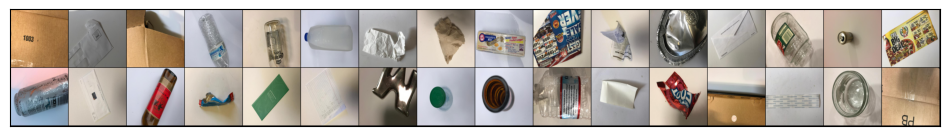

In [9]:
from torchvision.utils import make_grid

def show_batch(dl):
  for images, labels in dl:
    fig, ax = plt.subplots(figsize= (12,12))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.imshow(make_grid(images, nrow = 16).permute(1,2,0))
    break

show_batch(train_loader)

In [10]:
import torch.nn as nn
import torchvision.models as models

# Defining Classes
def Accuracy(outputs, labels):
  _, preds = torch.max(outputs, dim=1)
  return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassficationBase(nn.Module):

  def training_step(self, batch):
    images, labels = batch
    output = self(images)
    loss = F.cross_entropy(output, labels)
    return loss

  def validation_step(self, batch):
    images, labels = batch
    output = self(images)
    loss = F.cross_entropy(output, labels)
    acc = Accuracy(output, labels)
    return {f'val_loss': loss.detach(), 'val_acc': acc}

  def validation_epoch_end(self, outputs):
    batch_losses = [x['val_loss']for x in outputs]
    epoch_loss = torch.stack(batch_losses).mean()
    batch_accs = [x['val_acc'] for x in outputs]
    epoch_acc = torch.stack(batch_accs).mean()
    return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

  def epoch_end(self, epoch, result, is_best=False):
    msg = (
        f"Epoch {epoch} | "
        f"Train Acc: {result['train_acc']:.4f} | "
        f"Train Loss: {result['train_loss']:.4f} | "
        f"Val Loss: {result['val_loss']:.4f} | "
        f"Val Acc: {result['val_acc']:.4f}"
    )
    if is_best:
      msg += "  <-- Saving best model "
    print(msg)

In [11]:
import torch.nn as nn
import torchvision.models as models

class ResNet(ImageClassficationBase):

  def __init__(self):
    super().__init__()
    self.network = models.resnet50(pretrained = True)
    num_ftrs = self.network.fc.in_features

    # Adding Dropouts
    self.network.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, len(dataset.classes))
    )

  def forward(self, xb):
    return self.network(xb)

In [12]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet().to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 131MB/s]


In [13]:
import torch.optim as optim
opt_func = torch.optim.SGD

optimizer = opt_func(
    model.parameters(),
    lr=1e-3,
    momentum=0.9,
    weight_decay=1e-4
)

In [14]:
import torch
import torch.nn.functional as F

def fit(epochs, model, train_loader, val_loader, optimizer, device, checkpoint_path="best_model.pth"):

  history = []
  best_val_acc = 0.0  # to track the best validation accuracy

  for epoch in range(epochs):

    # --------- TRAINING ---------
    model.train()
    train_losses = []
    train_correct = 0
    train_total = 0

    for batch in train_loader:
      images, labels = batch
      images = images.to(device)
      labels = labels.to(device)

      # ONE forward pass only
      outputs = model(images)

      # loss (same as training_step was doing)
      loss = F.cross_entropy(outputs, labels)
      train_losses.append(loss)

      # train accuracy from the same outputs
      _, preds = torch.max(outputs, dim=1)
      train_correct += (preds == labels).sum().item()
      train_total += labels.size(0)

      # backward + optimize
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    train_loss = torch.stack(train_losses).mean().item()
    train_acc = train_correct / train_total

    # --------- VALIDATION ---------
    model.eval()
    with torch.no_grad():
        val_outputs = []
        for batch in val_loader:
            images, labels = batch
            images = images.to(device)
            labels = labels.to(device)

            out = model.validation_step((images, labels))
            val_outputs.append(out)

        result = model.validation_epoch_end(val_outputs)
        result['train_loss'] = train_loss
        result['train_acc'] = train_acc

    # --------- CHECK IF NEW BEST ---------
    val_acc = result['val_acc']
    is_best = val_acc > best_val_acc

    # --------- PRINT EPOCH RESULT ---------
    model.epoch_end(epoch + 1, result, is_best=is_best)
    history.append(result)

    # --------- CHECKPOINTING ---------
    if is_best:
        best_val_acc = val_acc
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": result['val_loss'],
                "val_acc": result['val_acc'],
            },
            checkpoint_path,
        )

  return history

In [15]:
epochs = 20
history = fit(epochs, model, train_loader, val_loader, optimizer,
              device, checkpoint_path="best_model.pth")

Epoch 1 | Train Acc: 0.5158 | Train Loss: 1.2731 | Val Loss: 0.7478 | Val Acc: 0.7239  <-- Saving best model 
Epoch 2 | Train Acc: 0.8360 | Train Loss: 0.5090 | Val Loss: 0.4994 | Val Acc: 0.8392  <-- Saving best model 
Epoch 3 | Train Acc: 0.9248 | Train Loss: 0.2634 | Val Loss: 0.3663 | Val Acc: 0.8740  <-- Saving best model 
Epoch 4 | Train Acc: 0.9638 | Train Loss: 0.1464 | Val Loss: 0.3487 | Val Acc: 0.8797  <-- Saving best model 
Epoch 5 | Train Acc: 0.9757 | Train Loss: 0.1136 | Val Loss: 0.3505 | Val Acc: 0.8762
Epoch 6 | Train Acc: 0.9898 | Train Loss: 0.0670 | Val Loss: 0.3784 | Val Acc: 0.8641
Epoch 7 | Train Acc: 0.9926 | Train Loss: 0.0544 | Val Loss: 0.3429 | Val Acc: 0.8845  <-- Saving best model 
Epoch 8 | Train Acc: 0.9915 | Train Loss: 0.0389 | Val Loss: 0.3147 | Val Acc: 0.8875  <-- Saving best model 
Epoch 9 | Train Acc: 0.9977 | Train Loss: 0.0282 | Val Loss: 0.2724 | Val Acc: 0.9136  <-- Saving best model 
Epoch 10 | Train Acc: 0.9977 | Train Loss: 0.0235 | Val Lo

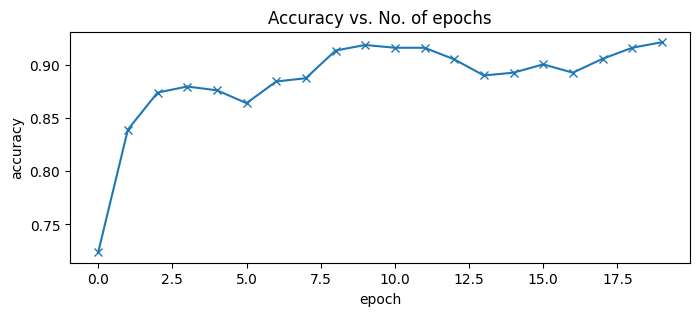

In [16]:
# Plotting the Accuracy
plt.figure(figsize = (8,3))

def plot_accuracy(history):
  accuracies = [x['val_acc'] for x in history]
  plt.plot(accuracies, '-x')
  plt.xlabel('epoch')
  plt.ylabel('accuracy')
  plt.title('Accuracy vs. No. of epochs')

plot_accuracy(history)

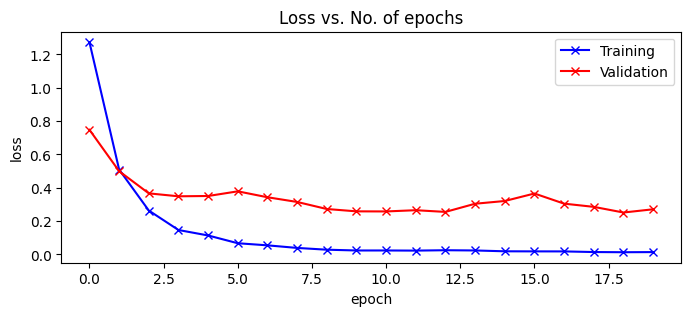

In [17]:
# Plotting the Loss
plt.figure(figsize=(8, 3))


def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs')


plot_losses(history)

In [18]:
checkpoint = torch.load("best_model.pth", map_location=device)
model = ResNet().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# evaluate on test_loader
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Store Prediction and True Label
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("="*30)
print(f"Test Acc: {correct/total*100:.3f}%")
print("="*30)

Test Acc: 90.263%


In [19]:
# Evaluating model on Accuracy, Precision, Recall, F1-Score, Confusion Matrix
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
# Accuracy
acc = accuracy_score(all_labels, all_preds)
# Precision
precision = precision_score(all_labels, all_preds, average='weighted')
# Recall
recall = recall_score(all_labels, all_preds, average='weighted')
# F1 - Score
f1 = f1_score(all_labels, all_preds, average='weighted')

print("="*30)

print(f"Accuracy : {acc*100:.3f}%")
print(f"Precision: {precision*100:.3f}")
print(f"Recall   : {recall*100:.3f}")
print(f"F1 Score : {f1*100:.3f}")

print("="*30)

Accuracy : 90.263%
Precision: 90.532
Recall   : 90.263
F1 Score : 90.081


In [20]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print(cm)

[[55  0  2  2  0  0]
 [ 0 72  2  1  3  0]
 [ 0  1 59  1  0  0]
 [ 0  1  1 88  1  1]
 [ 0  4  5  2 54  1]
 [ 3  0  3  3  0 15]]


In [21]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        59
           1       0.92      0.92      0.92        78
           2       0.82      0.97      0.89        61
           3       0.91      0.96      0.93        92
           4       0.93      0.82      0.87        66
           5       0.88      0.62      0.73        24

    accuracy                           0.90       380
   macro avg       0.90      0.87      0.88       380
weighted avg       0.91      0.90      0.90       380



In [22]:
%%writefile model.py

import torch
import torch.nn as nn
import torchvision.models as models

class ResNet(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.network = models.resnet50(pretrained=True)

        num_ftrs = self.network.fc.in_features

        self.network.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, num_classes)
        )

    def forward(self, xb):
        return self.network(xb)

Writing model.py


In [23]:
%%writefile class_names.py

class_names = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

Writing class_names.py


In [24]:
print(dataset.classes)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [42]:
%%writefile app.py
import streamlit as st
import torch
from PIL import Image
import torchvision.transforms as transforms
# From Created File
from model import ResNet
from class_names import class_names

# --------------------Page Config--------------------
st.set_page_config(
    page_title = 'Garbage Classifier',
    page_icon = '♻️',
    layout = 'wide'
)

# --------------------Custom CSS--------------------
st.markdown('''
<style>

.main{
  background-color: #07111f;
  color = white;
}

h1, h2, h3, h4, h5, h6{
  color: white !important;
}

.stButton>button{
  background-color: transparent;
  color: white;
  border: 2px solid #ff4b4b;
  border-radius: 10px;
  padding: 10px 20px;
  font-weight: bold;
}

.stButton>button:hover{
  background-color: #ff4b4b;
  color: white;
}

.card {
  background-color: #10243b;
  padding: 20px;
  border-radius: 15px;
  margin-bottom: 20px;
}

.result-card {
  background-color: #124d2e;
  padding: 20px;
  border-radius: 15px;
  font-size: 24px;
  font-weight: bold;
  text-align: center;
}

.info-card {
  background-color: #124d2e;
  padding: 15px;
  border-radius: 15px;
  margin-bottom: 15px;
}

</style>
''', unsafe_allow_html=True)

# To GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loading the Model We Created
model = ResNet(num_classes=len(class_names))

checkpoint = torch.load(
    "best_model.pth",
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)
model.to(device)
model.eval()

# Image Transformation
transformation = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.Normalize(
    #     mean=[0.485, 0.456, 0.406],
    #     std=[0.229, 0.224, 0.225]
    # )
])

# Defining a Prediction Function
def predict_image(image):

  image = transformation(image).unsqueeze(0).to(device)

  with torch.no_grad():

    outputs = model(image)
    probabilities = torch.softmax(outputs, dim=1)
    confidence, predicted = torch.max(probabilities, 1)

  predicted_class = class_names[predicted.item()]
  confidence_score = confidence.item()*100

  return predicted_class, confidence_score


# User Interface StreamLit
st.title('♻️ Garbage Image Classification')

st.write(
    'Upload a waste image to identify its type and understand its environmental impact.'
)

# Uploading a Image
uploaded_file = st.file_uploader(
    'Upload an image (JPG, PNG, JPEG)',
    type=["jpg", "jpeg", "png"]
)

# Classify Button
if uploaded_file is not None:

  image = Image.open(uploaded_file)
  image = image.convert('RGB')
  classify = st.button("Classify")

  if classify:
    prediction, confidence = predict_image(image)
    # 3 Column Layout
    col1, col2, col3 = st.columns(3)

    # Column 1
    with col1:
      st.markdown(
          '<div class = "card"><h3>Upload Image</h3></div>',
          unsafe_allow_html=True
      )
      st.image(image, caption='Uploaded Image', use_container_width = True,)

    with col2:
      st.markdown(
          '<div class="card"><h3>Classification Result</h3></div>',
          unsafe_allow_html = True
      )
      st.markdown(
          f'''
          <div class="result-card">
            The Image is Predicted as: {prediction}
            <br><br>
            The Confidence is: {confidence:.2f}%
          </div>
      ''',unsafe_allow_html=True
          )

    with col3:
      st.markdown(
          '<div class="card"><h3>Environmental Awareness</h3></div>',
          unsafe_allow_html = True
      )
      if prediction.lower() == "metal":
        st.markdown(
            '''
            <div class = 'info-card'>
            ♻️ Metal waste can be recycled efficiently.
            </div>
            ''',
            unsafe_allow_html = True
        )

        st.markdown(
            '''
            <div class="info-card">
            Aluminum recycling saves huge energy.
            </div>
            ''',
            unsafe_allow_html = True
        )

        st.markdown(
            '''
            <div class="info-card">
            Recycling metals reduces CO₂ emissions.
            </div>
            ''',
            unsafe_allow_html=True
        )

      elif prediction.lower() == 'plastic':
        st.markdown(
            '''
            <div class="info-card">
            ♻️ Plastic waste harms oceans and animals.
            </div>
            ''',
            unsafe_allow_html = True
        )

        st.markdown(
            '''
            <div class="info-card">
            Recycle plastics to reduce pollution.
            </div>
            ''',
            unsafe_allow_html=True
        )

      elif prediction.lower() == 'paper':
        st.markdown(
            '''
            <div class="info-card">
            🌳 Recycling paper saves trees and water.
            </div>
            ''',
            unsafe_allow_html = True
        )
      else:
        st.markdown(
            '''
            <div class="info-card">
            Proper waste segregation helps the environment.
            </div>
            ''',
            unsafe_allow_html = True
        )
    st.success(f"The image is classified as {prediction}")


Overwriting app.py


In [43]:
!pip install streamlit pyngrok -q

In [44]:
from pyngrok import ngrok

ngrok.set_auth_token('3E4vzUjxf1495oABloqd3MHctUK_4kSV2s3ndEf4YsB3PdKtW')

In [45]:
!streamlit run app.py &>/content/logs.txt &

In [46]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://rearview-colt-subtly.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
ngrok.kill()

In [ ]:
print(dataset.classes)